<a href="https://colab.research.google.com/github/BasuAI/BasuAI/blob/main/CNNLandCover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install some packages
!pip install rasterio
!pip install earthpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 13.1 MB/s eta 0:00:00


In [ ]:
# Import packages
import pandas as pd
import numpy as np
import keras
from keras import Sequential
from keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten, Input, GlobalMaxPooling1D
from keras.callbacks import EarlyStopping
from keras import Model
import rasterio
import earthpy.plot as ep
from keras.utils import to_categorical, plot_model, model_to_dot
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import from_levels_and_colors

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Mount GDRIVE
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Parameter
FEATURES = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'EVI', 'NBR', 'NDMI', 'NDWI', 'NDBI', 'NDBaI', 'elevation']
LABEL = ['Class']
SPLIT = ['sample']
N_CLASSES = 8
CLASSES = [1, 2, 3, 4, 5, 6, 7, 8]
PALETTE = ['#047cb6', '#a8acbf', '#195567', '#f95965', '#fbc623', '#cbfbfd', '#46D883', '#A250CE']
SAMPLE_PATH = '/content/drive/MyDrive/DL/Samples_NTPA_2024.csv'
IMAGE_PATH = '/content/drive/MyDrive/DL/Landsat_NTPA_2024.tif'

/usr/local/lib/python3.12/dist-packages/earthpy/spatial.py:561: RuntimeWarning: invalid value encountered in cast
  return (bytedata.clip(low, high) + 0.5).astype("uint8")


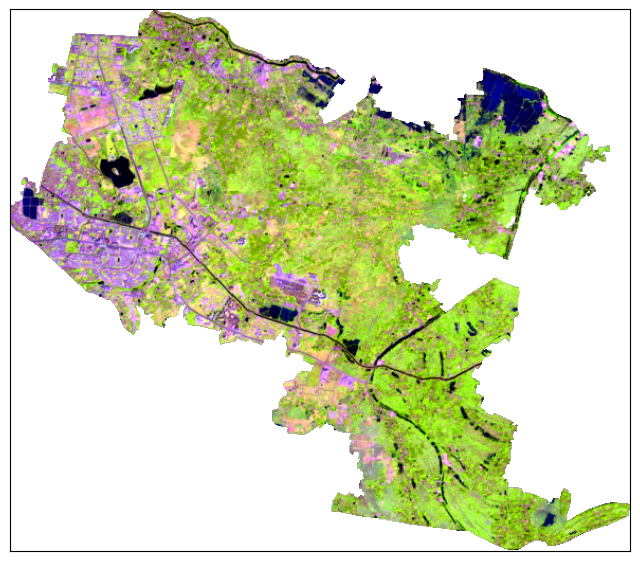

<Axes: >

In [ ]:
# Load image
image = rasterio.open(IMAGE_PATH)
bandNum = image.count
height = image.height
width = image.width
crs = image.crs
transform = image.transform
shape = (height, width)

image_vis = []
for x in [6, 5, 4]:
  image_vis.append(image.read(x))
image_vis = np.stack(image_vis)

plot_size = (8, 8)
ep.plot_rgb(
  image_vis,
  figsize=plot_size,
  stretch=True,
)

In [ ]:
# Read sample
samples = pd.read_csv(SAMPLE_PATH)
samples = samples.sample(frac = 1) # Shuffle data
samples

,B1,B2,B3,B4,B5,B6,B7,EVI,NBR,NDMI,NDWI,NDBI,NDBaI,elevation,Class,sample
14913,0.045657,0.053000,0.084487,0.069445,0.280329,0.199259,0.112180,0.405702,0.428395,0.169041,-0.536822,-0.169041,0.279602,-1,8,test
12472,0.050250,0.058761,0.089768,0.081105,0.256596,0.223376,0.129161,0.336831,0.330350,0.069212,-0.481658,-0.069212,0.267248,1,5,train
9323,0.042550,0.053275,0.083415,0.070902,0.257682,0.178070,0.095047,0.363800,0.461075,0.182701,-0.510902,-0.182701,0.303981,1,4,test
4659,0.071549,0.085464,0.107959,0.114490,0.209008,0.242379,0.192975,0.188286,0.039884,-0.073931,-0.318800,0.073931,0.113480,-2,2,train
9177,0.072717,0.089589,0.124527,0.131444,0.238900,0.203535,0.146968,0.198164,0.238249,0.079933,-0.314705,-0.079933,0.161390,0,4,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1588,0.050415,0.065265,0.094992,0.077585,0.070462,0.038590,0.026462,-0.017015,0.453959,0.292267,0.148258,-0.292267,0.186426,0,1,test
14312,0.047679,0.056575,0.089905,0.071370,0.271570,0.189263,0.111506,0.392402,0.417838,0.178606,-0.502566,-0.178606,0.258525,4,8,train
368,0.042082,0.055503,0.087788,0.074203,0.076347,0.033062,0.022117,0.004852,0.550754,0.395622,0.069699,-0.395622,0.198351,2,1,train
14143,0.037985,0.048724,0.092380,0.060026,0.367229,0.177272,0.087375,0.563899,0.615599,0.348863,-0.598006,-0.348863,0.339688,0,8,train


In [ ]:
# Split into train and test based on column
train = samples[samples['sample'] == 'train']
test = samples[samples['sample'] == 'test']

# Split between features and label
train_features = train[FEATURES]
train_label = train[LABEL]
test_features = test[FEATURES]
test_label = test[LABEL]

# Function to reshape array input
def reshape_input(array):
  shape = array.shape
  return array.reshape(shape[0], shape[1], 1)

# Convert samples dataframe (pandas) to numpy array
train_input = reshape_input(train_features.to_numpy())
test_input = reshape_input(test_features.to_numpy())

# Also make label data to categorical
train_output = to_categorical(train_label.to_numpy(), N_CLASSES + 1)
test_output = to_categorical(test_label.to_numpy(), N_CLASSES + 1)

# Show the data shape
print(f'Train features: {train_input.shape}\nTest features: {test_input.shape}\nTrain label: {train_output.shape}\nTest label: {test_output.shape}')

Train features: (12140, 14, 1)
Test features: (2842, 14, 1)
Train label: (12140, 9)
Test label: (2842, 9)


In [ ]:
# Make model for our data
# Input shape
train_shape = train_input.shape
input_shape = (train_shape[1], train_shape[2])

# Model parameter
neuron = 64
drop = 0.2
kernel = 3
pool = 2

# Make sequential model
model = Sequential([
  Input(input_shape),
  Conv1D(neuron * 1, kernel, activation='relu'),
  Conv1D(neuron * 1, kernel, activation='relu'),
  MaxPooling1D(pool),
  Dropout(drop),
  Conv1D(neuron * 2, kernel, activation='relu'),
  Conv1D(neuron * 2, kernel, activation='relu'),
  GlobalMaxPooling1D(), # Changed pool size to 1
  Dropout(drop),
  GlobalMaxPooling1D(),
  Dense(neuron * 2, activation='relu'),
  Dropout(drop),
  Dense(neuron * 1, activation='relu'),
  Dropout(drop),
  Dense(N_CLASSES + 1, activation='softmax')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_16 (Conv1D)              │ (None, 12, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 10, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 8, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 6, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 4, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 2, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_5          │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,545 (1.87 MB)

 Trainable params: 489,545 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model

# Compline the model
model.compile(
    optimizer='Adam',
    loss='CategoricalCrossentropy',
    metrics=['accuracy']
)

# Create callback to stop training if loss not decreasing
stop = EarlyStopping(
    monitor='loss',
    patience=5
)

# Fit the model
result = model.fit(
    x=train_input, y=train_output,
    validation_data=(test_input, test_output),
    batch_size=128,
    callbacks=[stop],
    epochs=50,
)

Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - accuracy: 0.3218 - loss: 1.7553 - val_accuracy: 0.7182 - val_loss: 0.8571
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.6874 - loss: 0.9398 - val_accuracy: 0.7343 - val_loss: 0.8182
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.7197 - loss: 0.8638 - val_accuracy: 0.7129 - val_loss: 0.8345
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - accuracy: 0.7225 - loss: 0.8455 - val_accuracy: 0.7505 - val_loss: 0.7454
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.7378 - loss: 0.7837 - val_accuracy: 0.7544 - val_loss: 0.7225
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.7412 - loss: 0.7663 - val_accuracy: 0.7555 - val_loss: 0.7013
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.7461 - loss: 0.7618 - val_accuracy: 0.7716 - val_loss: 0.6864
Epoch 8/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.7509 - loss: 0.7398 - val_accuracy: 

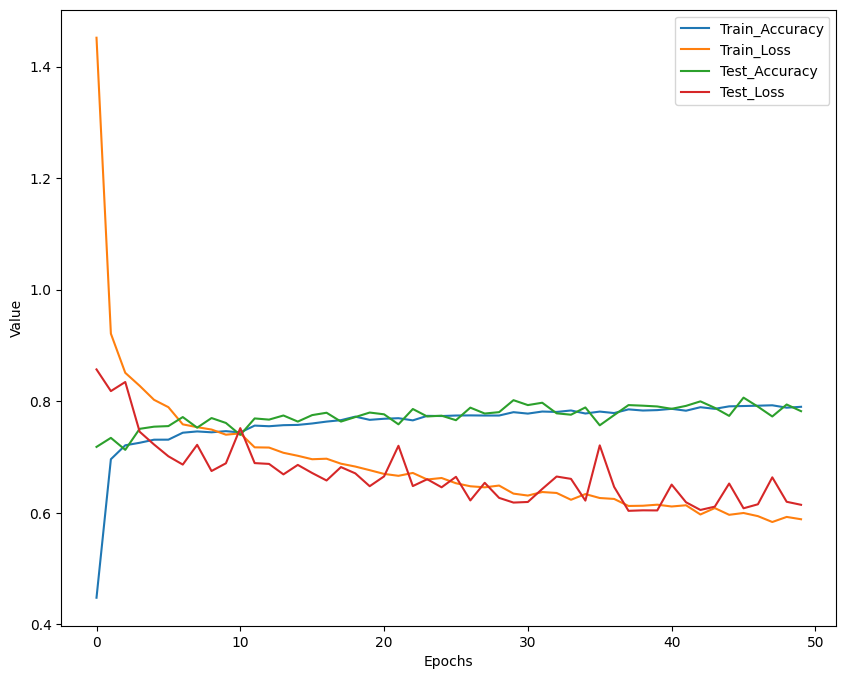

In [ ]:
# Show history
history = pd.DataFrame(result.history)

plt.figure(figsize = (10, 8))
plt.plot(range(len(history['accuracy'].values.tolist())), history['accuracy'].values.tolist(), label = 'Train_Accuracy')
plt.plot(range(len(history['loss'].values.tolist())), history['loss'].values.tolist(), label = 'Train_Loss')
plt.plot(range(len(history['val_accuracy'].values.tolist())), history['val_accuracy'].values.tolist(), label = 'Test_Accuracy')
plt.plot(range(len(history['val_loss'].values.tolist())), history['val_loss'].values.tolist(), label = 'Test_Loss')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.show()

89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
              precision    recall  f1-score   support

           1       0.92      0.89      0.90       390
           2       0.73      0.80      0.76       474
           3       0.68      0.84      0.75       359
           4       0.92      0.84      0.88       519
           5       0.75      0.84      0.79       806
           6       0.24      0.23      0.24        39
           7       0.00      0.00      0.00         7
           8       0.89      0.32      0.47       248

    accuracy                           0.78      2842
   macro avg       0.64      0.59      0.60      2842
weighted avg       0.79      0.78      0.77      2842



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


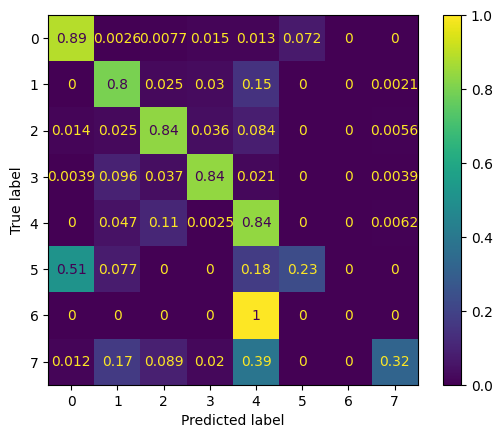

In [ ]:
# Predict test data
prediction = np.argmax(model.predict(test_input), 1).flatten()
label = np.argmax(test_output, 1).flatten()

# Confusion matrix
cm = confusion_matrix(label, prediction, normalize='true')
cm = ConfusionMatrixDisplay(cm)
cm.plot()

# Classification report
print(classification_report(label, prediction))

15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step


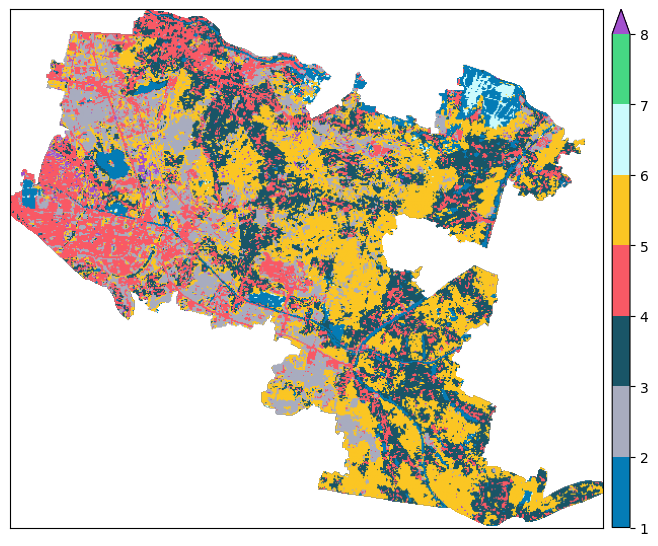

<Axes: >

In [ ]:
# Predict image using the model
image_input = []
for x in range(14):
  image_input.append(image.read(x + 1))
image_input = reshape_input(np.stack(image_input).reshape(14, -1).T)

# Predict
prediction = model.predict(image_input, batch_size=1024*20)
prediction = np.argmax(prediction, 1)
prediction = prediction.reshape(shape[0], shape[1])

# Visualize
cmap, norm = from_levels_and_colors(CLASSES, PALETTE, extend='max')
ep.plot_bands(prediction, cmap=cmap, norm=norm, figsize=plot_size)

In [ ]:
# Save file to drive
save_location = '/content/drive/MyDrive/DL/'
name = 'LC_Jambi_2023.tif'
location = save_location + name

new_dataset = rasterio.open(
      location,
      mode='w', driver='GTiff',
      height = prediction.shape[0], width = prediction.shape[1],
      count=1, dtype=str(prediction.dtype),
      crs=crs,
      transform=transform
)
new_dataset.write(prediction, 1);
new_dataset.close()